In [13]:
import warnings
warnings.filterwarnings('ignore')

# [1] && [2]

In [14]:
import pandas as pd

df = pd.read_csv('WineQT.csv')

dims = df.shape
num_features = len(df.columns) - 2  # Исключаем 'quality' (целевая) и 'Id'
class_counts = df['quality'].value_counts().sort_index()
num_classes = len(class_counts)
missing_values = df.isnull().sum().sum()
percent_missing = (missing_values / (df.shape[0] * df.shape[1])) * 100
feature_types = df.dtypes
quality_mean = df['quality'].mean()
quality_std = df['quality'].std()
duplicates = df.duplicated().sum()

print(f"Dimensionality of the dataset: {dims[0]} rows × {dims[1]} columns")
print(f"Number of features: {num_features}")
print(f"Number of target classes: {num_classes} (quality scores: {', '.join(map(str, class_counts.index))})")
print(f"Objects in each class: {', '.join(f'{k}: {v}' for k, v in class_counts.items())}")
print(f"Percentage of objects with undefined features: {percent_missing:.2f}%")
print("Other key characteristics:" + 
      f"\n- All features types: {', '.join(f'{k}: {v}' for k, v in feature_types.items())}" +
      f"\n- Quality ranges from {df['quality'].min()} to {df['quality'].max()} with mean {quality_mean:.2f} and std {quality_std:.2f}" +
      f"\n- Duplicates: {duplicates}")

selected_classes = [4, 6, 7]
filtered_df = df[df['quality'].isin(selected_classes)]
selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar']
filtered_df = filtered_df.dropna(subset=selected_features)
filtered_df = filtered_df[selected_features + ['quality']]

filtered_df.to_csv('filtered_WineQT.csv', index=False)
print('filtered DataFrame saved to: filtered_WineQT.csv')

Dimensionality of the dataset: 1143 rows × 13 columns
Number of features: 11
Number of target classes: 6 (quality scores: 3, 4, 5, 6, 7, 8)
Objects in each class: 3: 6, 4: 33, 5: 483, 6: 462, 7: 143, 8: 16
Percentage of objects with undefined features: 0.00%
Other key characteristics:
- All features types: fixed acidity: float64, volatile acidity: float64, citric acid: float64, residual sugar: float64, chlorides: float64, free sulfur dioxide: float64, total sulfur dioxide: float64, density: float64, pH: float64, sulphates: float64, alcohol: float64, quality: int64, Id: int64
- Quality ranges from 3 to 8 with mean 5.66 and std 0.81
- Duplicates: 0
filtered DataFrame saved to: filtered_WineQT.csv


# [3] && [4]

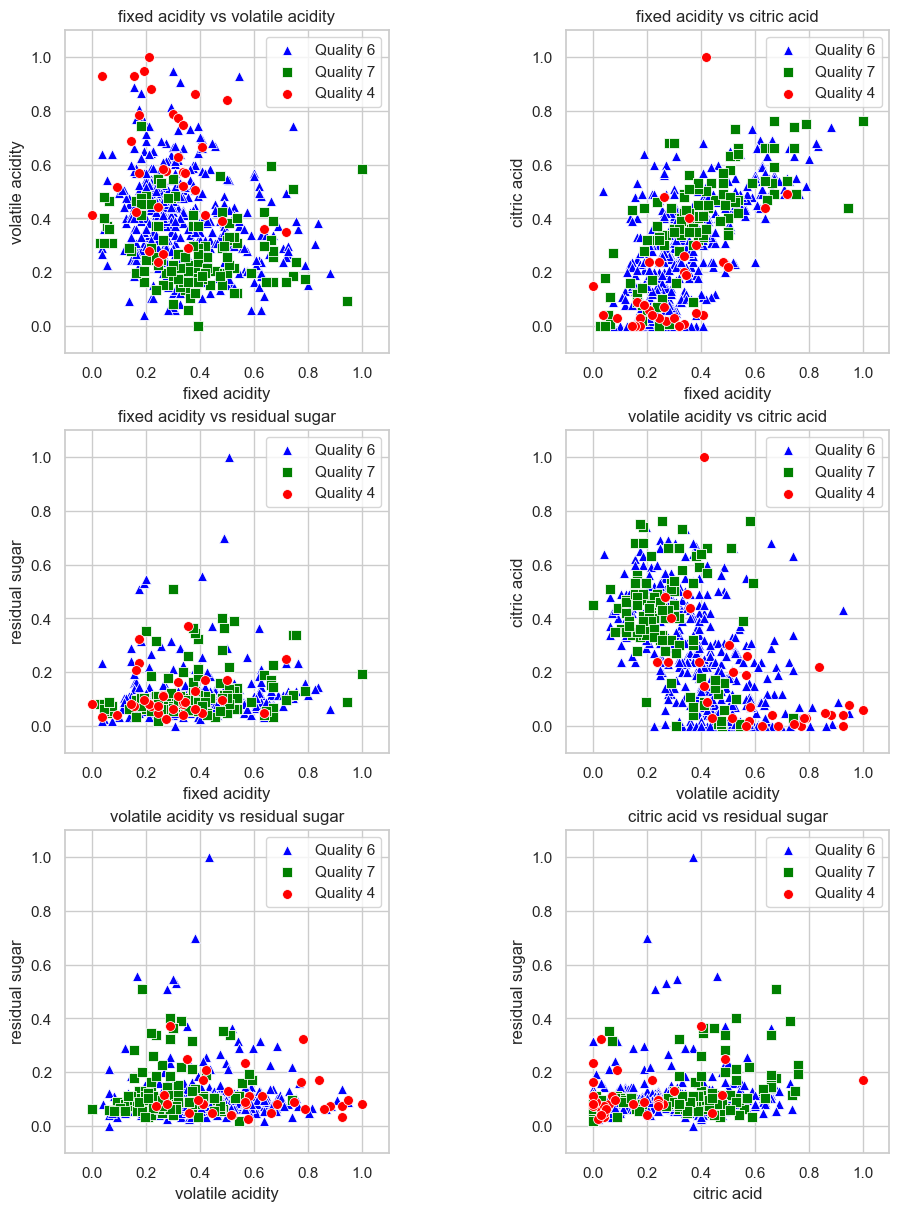

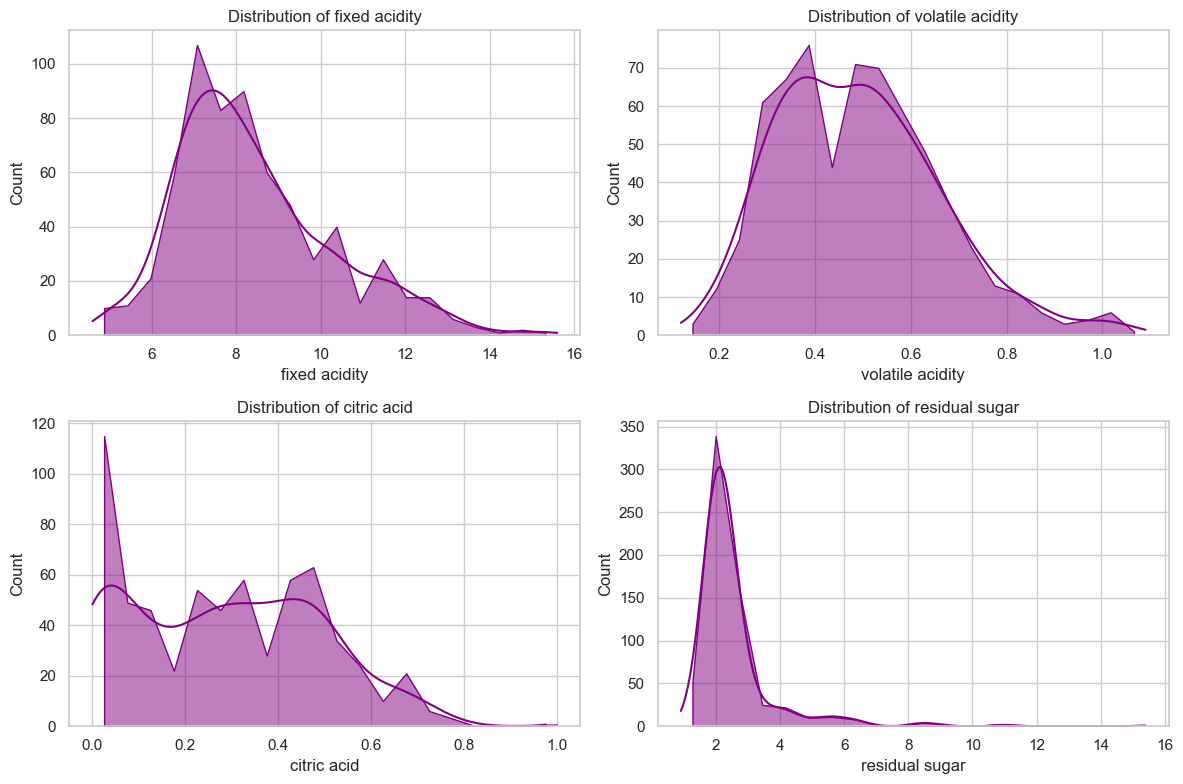


Pearson Correlation Matrix (All Data):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            1.0000           -0.2784       0.6894          0.1548
volatile acidity        -0.2784            1.0000      -0.5771         -0.0046
citric acid              0.6894           -0.5771       1.0000          0.1775
residual sugar           0.1548           -0.0046       0.1775          1.0000

Pearson P-values (All Data):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            0.0000             0.000          0.0          0.0001
volatile acidity         0.0000             0.000          0.0          0.9080
citric acid              0.0000             0.000          0.0          0.0000
residual sugar           0.0001             0.908          0.0          0.0000

Spearman Correlation Matrix (All Data):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity       

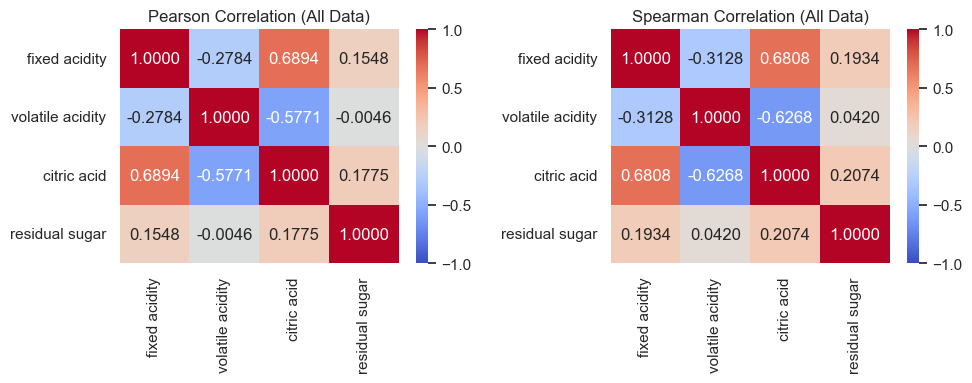


Pearson Correlation Matrix (Quality 6):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            1.0000           -0.2757       0.6870          0.1227
volatile acidity        -0.2757            1.0000      -0.5702          0.0178
citric acid              0.6870           -0.5702       1.0000          0.0912
residual sugar           0.1227            0.0178       0.0912          1.0000

Pearson P-values (Quality 6):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            0.0000            0.0000         0.00          0.0083
volatile acidity         0.0000            0.0000         0.00          0.7031
citric acid              0.0000            0.0000         0.00          0.0500
residual sugar           0.0083            0.7031         0.05          0.0000

Spearman Correlation Matrix (Quality 6):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity    

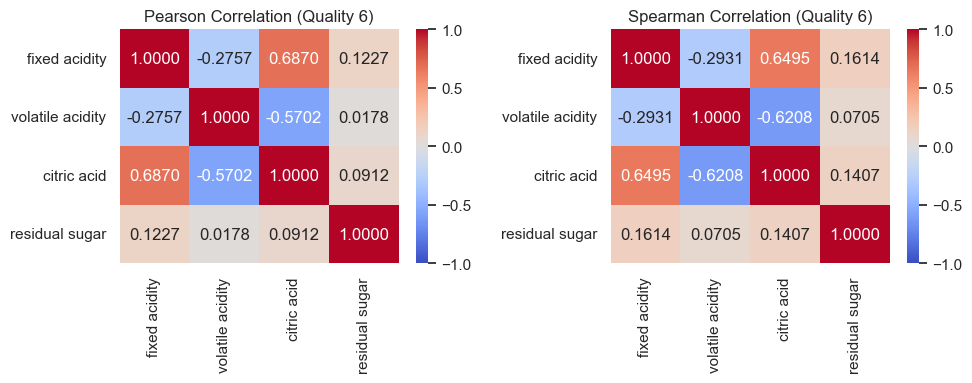


Pearson Correlation Matrix (Quality 7):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            1.0000           -0.1678       0.7179          0.1979
volatile acidity        -0.1678            1.0000      -0.3971          0.1049
citric acid              0.7179           -0.3971       1.0000          0.3375
residual sugar           0.1979            0.1049       0.3375          1.0000

Pearson P-values (Quality 7):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            0.0000            0.0451          0.0          0.0178
volatile acidity         0.0451            0.0000          0.0          0.2126
citric acid              0.0000            0.0000          0.0          0.0000
residual sugar           0.0178            0.2126          0.0          0.0000

Spearman Correlation Matrix (Quality 7):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity    

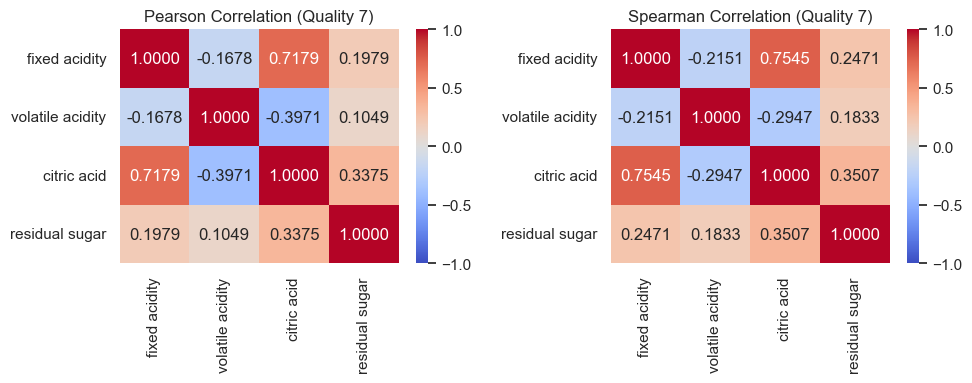


Pearson Correlation Matrix (Quality 4):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            1.0000           -0.2604       0.5134          0.1709
volatile acidity        -0.2604            1.0000      -0.5671         -0.1934
citric acid              0.5134           -0.5671       1.0000          0.2770
residual sugar           0.1709           -0.1934       0.2770          1.0000

Pearson P-values (Quality 4):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            0.0000            0.1433       0.0022          0.3418
volatile acidity         0.1433            0.0000       0.0006          0.2808
citric acid              0.0022            0.0006       0.0000          0.1187
residual sugar           0.3418            0.2808       0.1187          0.0000

Spearman Correlation Matrix (Quality 4):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity    

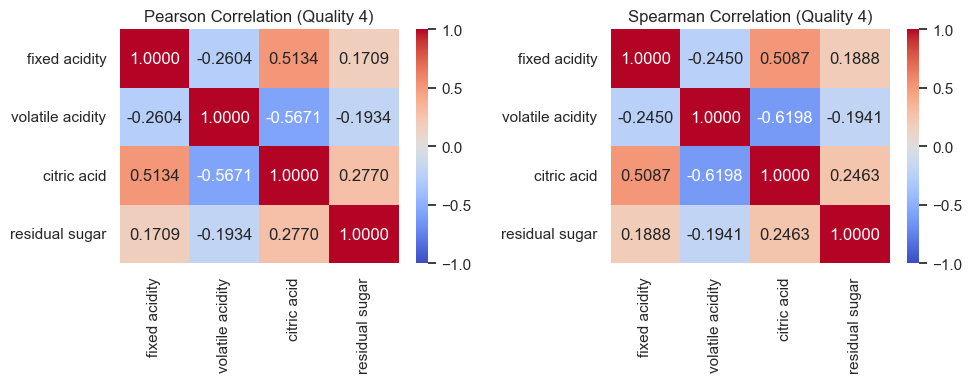

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from scipy.stats import pearsonr, spearmanr

%matplotlib inline

df = pd.read_csv('filtered_WineQT.csv')

class_styles = {
    4: {'color': 'red', 'marker': 'o'},
    6: {'color': 'blue', 'marker': '^'},
    7: {'color': 'green', 'marker': 's'}
}

sns.set_theme(style="whitegrid")

selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar']
pairs = list(itertools.combinations(selected_features, 2))

# Нормализация данных, чтобы не было диспропорциональных сторон по типу
# citric acid 0.0 0.2 0.4 0.6 0.8 1.0 && residual sugar 5 10 15
df_norm = df.copy()
for feature in selected_features:
    df_norm[feature] = (df[feature] - df[feature].min()) / (df[feature].max() - df[feature].min())

# Диаграммы рассеяния
plt.figure(figsize=(10, 12), constrained_layout=True)  # Увеличить высоту для 3 рядов
for i, (x_feature, y_feature) in enumerate(pairs, 1):
    ax = plt.subplot(3, 2, i)
    for quality in df['quality'].unique():
        subset = df_norm[df_norm['quality'] == quality]
        sns.scatterplot(data=subset, x=x_feature, y=y_feature, 
                        color=class_styles[quality]['color'], 
                        marker=class_styles[quality]['marker'], 
                        label=f'Quality {quality}', s=50)
    ax.set_aspect('equal')  # Квадратное соотношение сторон
    ax.set_xlim(-0.1, 1.1)  # Унифицированный масштаб 0–1
    ax.set_ylim(-0.1, 1.1)
    plt.title(f'{x_feature} vs {y_feature}')
plt.show()

# Гистограммы распределения признаков
plt.figure(figsize=(12, 8))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=feature, bins=20,
                 kde=True, color='purple', alpha=0.5, 
                 element='poly')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

def compute_correlations(data, features, method='pearson'):
    corr_matrix = pd.DataFrame(index=features, columns=features)
    pval_matrix = pd.DataFrame(index=features, columns=features)

    for f1, f2 in itertools.combinations(features, 2):
        if method == 'pearson':
            corr, pval = pearsonr(data[f1], data[f2])
        elif method == 'spearman':
            corr, pval = spearmanr(data[f1], data[f2])
        corr_matrix.loc[f1, f2] = corr
        corr_matrix.loc[f2, f1] = corr
        pval_matrix.loc[f1, f2] = pval
        pval_matrix.loc[f2, f1] = pval
    
    # Заполняем диагональ (корреляция признака с самим собой)
    for f in features:
        corr_matrix.loc[f, f] = 1.0
        pval_matrix.loc[f, f] = 0.0
    
    return corr_matrix.astype(float), pval_matrix.astype(float)

pearson_corr, pearson_pval = compute_correlations(df, selected_features, method='pearson')
spearman_corr, spearman_pval = compute_correlations(df, selected_features, method='spearman')

print("\nPearson Correlation Matrix (All Data):")
print(pearson_corr.round(4))
print("\nPearson P-values (All Data):")
print(pearson_pval.round(4))
print("\nSpearman Correlation Matrix (All Data):")
print(spearman_corr.round(4))
print("\nSpearman P-values (All Data):")
print(spearman_pval.round(4))

# Тепловые карты корреляций для всего датасета
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.4f')
plt.title('Pearson Correlation (All Data)')
plt.subplot(1, 2, 2)
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.4f')
plt.title('Spearman Correlation (All Data)')
plt.tight_layout()
plt.show()

# Вычисление и вывод корреляций для каждого класса
for quality in df['quality'].unique():
    subset = df[df['quality'] == quality]
    pearson_corr, pearson_pval = compute_correlations(subset, selected_features, method='pearson')
    spearman_corr, spearman_pval = compute_correlations(subset, selected_features, method='spearman')
    
    print(f"\n{'='*50}")
    print(f"Pearson Correlation Matrix (Quality {quality}):")
    print(pearson_corr.round(4))
    print(f"\nPearson P-values (Quality {quality}):")
    print(pearson_pval.round(4))
    print(f"\nSpearman Correlation Matrix (Quality {quality}):")
    print(spearman_corr.round(4))
    print(f"\nSpearman P-values (Quality {quality}):")
    print(spearman_pval.round(4))
    
    # Тепловые карты для каждого класса
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.4f')
    plt.title(f'Pearson Correlation (Quality {quality})')
    plt.subplot(1, 2, 2)
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.4f')
    plt.title(f'Spearman Correlation (Quality {quality})')
    plt.tight_layout()
    plt.show()

# [5]

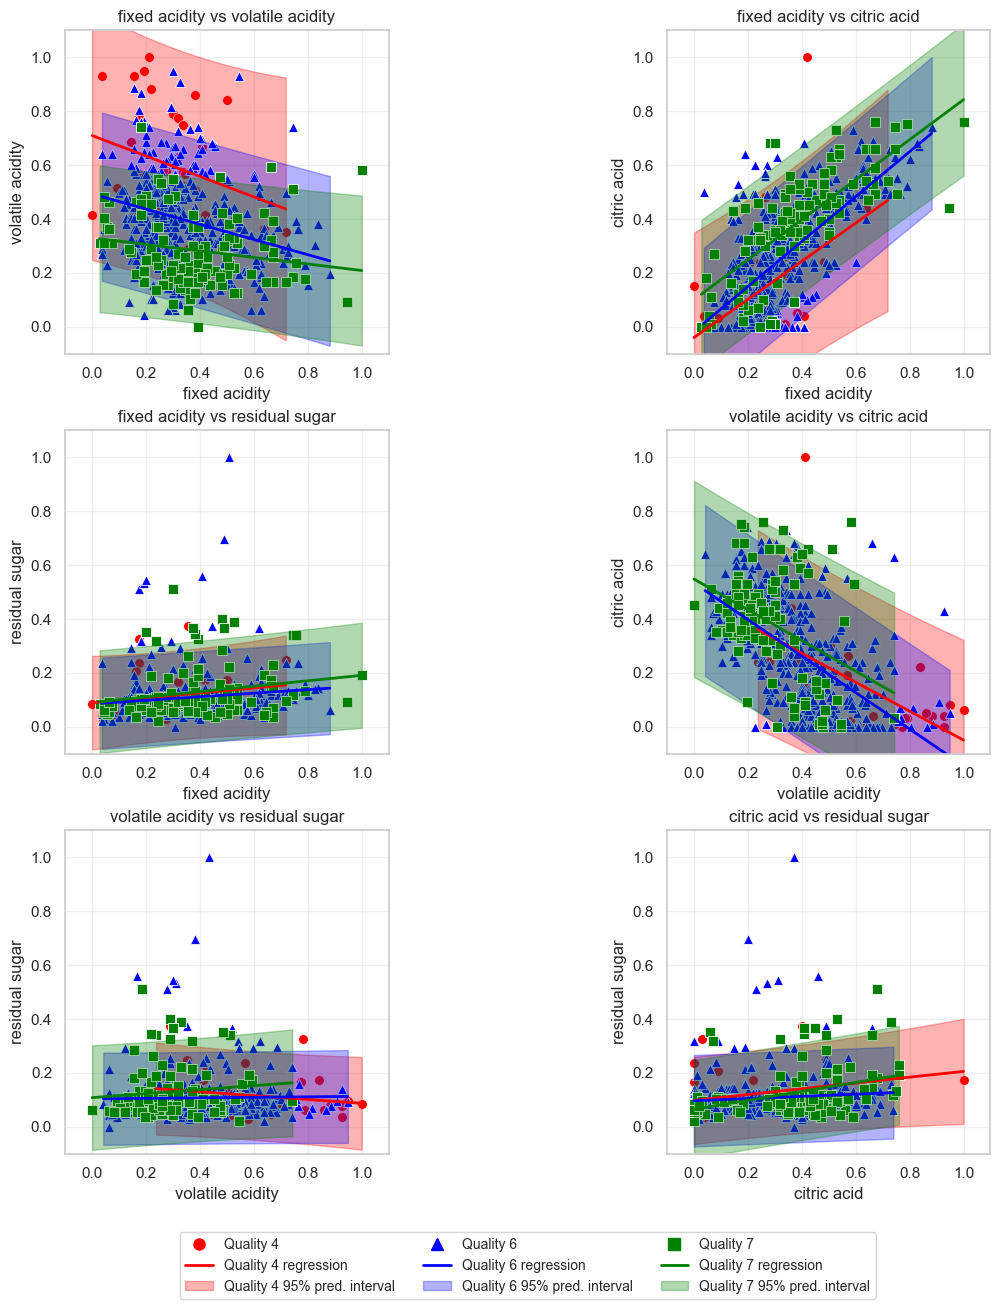

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats

%matplotlib inline

df = pd.read_csv('filtered_WineQT.csv')

class_styles = {
    4: {'color': 'red', 'marker': 'o', 'label': 'Quality 4'},
    6: {'color': 'blue', 'marker': '^', 'label': 'Quality 6'},
    7: {'color': 'green', 'marker': 's', 'label': 'Quality 7'}
}

sns.set_theme(style="whitegrid")

selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar']
pairs = list(itertools.combinations(selected_features, 2))

# Нормализация данных
df_norm = df.copy()
for feature in selected_features:
    df_norm[feature] = (df[feature] - df[feature].min()) / (df[feature].max() - df[feature].min())

def add_regression_line(ax, x_data, y_data, color, label, alpha=0.3, show_regression_label=False, show_interval_label=False):
    # Проверяем, достаточно ли данных для регрессии
    if len(x_data) < 2:
        return None, None  # Возвращаем None, если нет данных для регрессии
    
    # Подготовка данных как одномерных массивов
    x = x_data.values.flatten()
    y = y_data.values.flatten()
    
    # Линейная регрессия
    model = LinearRegression()
    X = x.reshape(-1, 1)
    model.fit(X, y)
    
    # Создание точек для плавной линии
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    
    # Расчет предсказательных интервалов
    y_pred = model.predict(X)
    residuals = y - y_pred
    mse = np.mean(residuals**2)
    
    # Статистические параметры
    n = len(y)
    k = 1  # количество предикторов (только X)
    df = n - k - 1  # степени свободы
    
    # Стандартная ошибка для предсказательных интервалов
    X_design = np.column_stack([np.ones(n), x])  # Дизайн-матрица
    XTX_inv = np.linalg.inv(X_design.T @ X_design)
    X_line_design = np.column_stack([np.ones(len(x_line)), x_line.flatten()])
    se_pred = np.sqrt(mse * (1 + np.diag(X_line_design @ XTX_inv @ X_line_design.T)))
    
    # 95% предсказательные интервалы
    t_critical = stats.t.ppf(0.975, df)  # 97.5% квантиль для двухстороннего интервала
    y_lower = y_line.flatten() - t_critical * se_pred
    y_upper = y_line.flatten() + t_critical * se_pred
    
    line_handle, = ax.plot(x_line.flatten(), y_line, color=color, linewidth=2, label=None)
    interval_handle = ax.fill_between(x_line.flatten(), y_lower, y_upper, color=color, alpha=alpha, label=None)
    
    return line_handle, interval_handle

def create_legend_handles():
    handles = []
    labels = []
    for quality in sorted(class_styles.keys()):
        style = class_styles[quality]
        # Создаем placeholder для точки
        point_handle, = plt.plot([], [], color=style['color'], marker=style['marker'], 
                                linestyle='', markersize=8, label=style['label'])
        # Создаем placeholder для линии регрессии
        line_handle, = plt.plot([], [], color=style['color'], linewidth=2, 
                               label=f'{style["label"]} regression')
        # Создаем placeholder для интервала (используем patch)
        from matplotlib.patches import Patch
        interval_patch = Patch(color=style['color'], alpha=0.3, 
                              label=f'{style["label"]} 95% pred. interval')
        
        handles.extend([point_handle, line_handle, interval_patch])
        labels.extend([style['label'], f'{style["label"]} regression', 
                      f'{style["label"]} 95% pred. interval'])
    
    return handles, labels

# Диаграммы рассеяния с линиями регрессии для всех пар признаков
fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)  # Квадратная фигура
axes = axes.flatten()

for i, (x_feature, y_feature) in enumerate(pairs):
    ax = axes[i]
    
    # Построение точек для каждого класса
    for quality in sorted(class_styles.keys()):
        subset = df_norm[df_norm['quality'] == quality]
        if len(subset) > 0:
            style = class_styles[quality]
            sns.scatterplot(data=subset, x=x_feature, y=y_feature, 
                            color=style['color'], marker=style['marker'], 
                            label='_nolegend_', s=50, ax=ax)
            
            add_regression_line(ax, subset[x_feature], subset[y_feature], 
                              style['color'], style['label'])
    
    ax.set_aspect('equal')  # Квадратное соотношение сторон
    ax.set_xlim(-0.1, 1.1)  # Унифицированный масштаб
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(f'{x_feature} vs {y_feature}')
    ax.grid(True, alpha=0.3)

# Удаление пустых subplot'ов
for j in range(len(pairs), len(axes)):
    fig.delaxes(axes[j])

handles, labels = create_legend_handles()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, -0.05), 
           ncol=3, fontsize='small')
plt.show()

# [6]

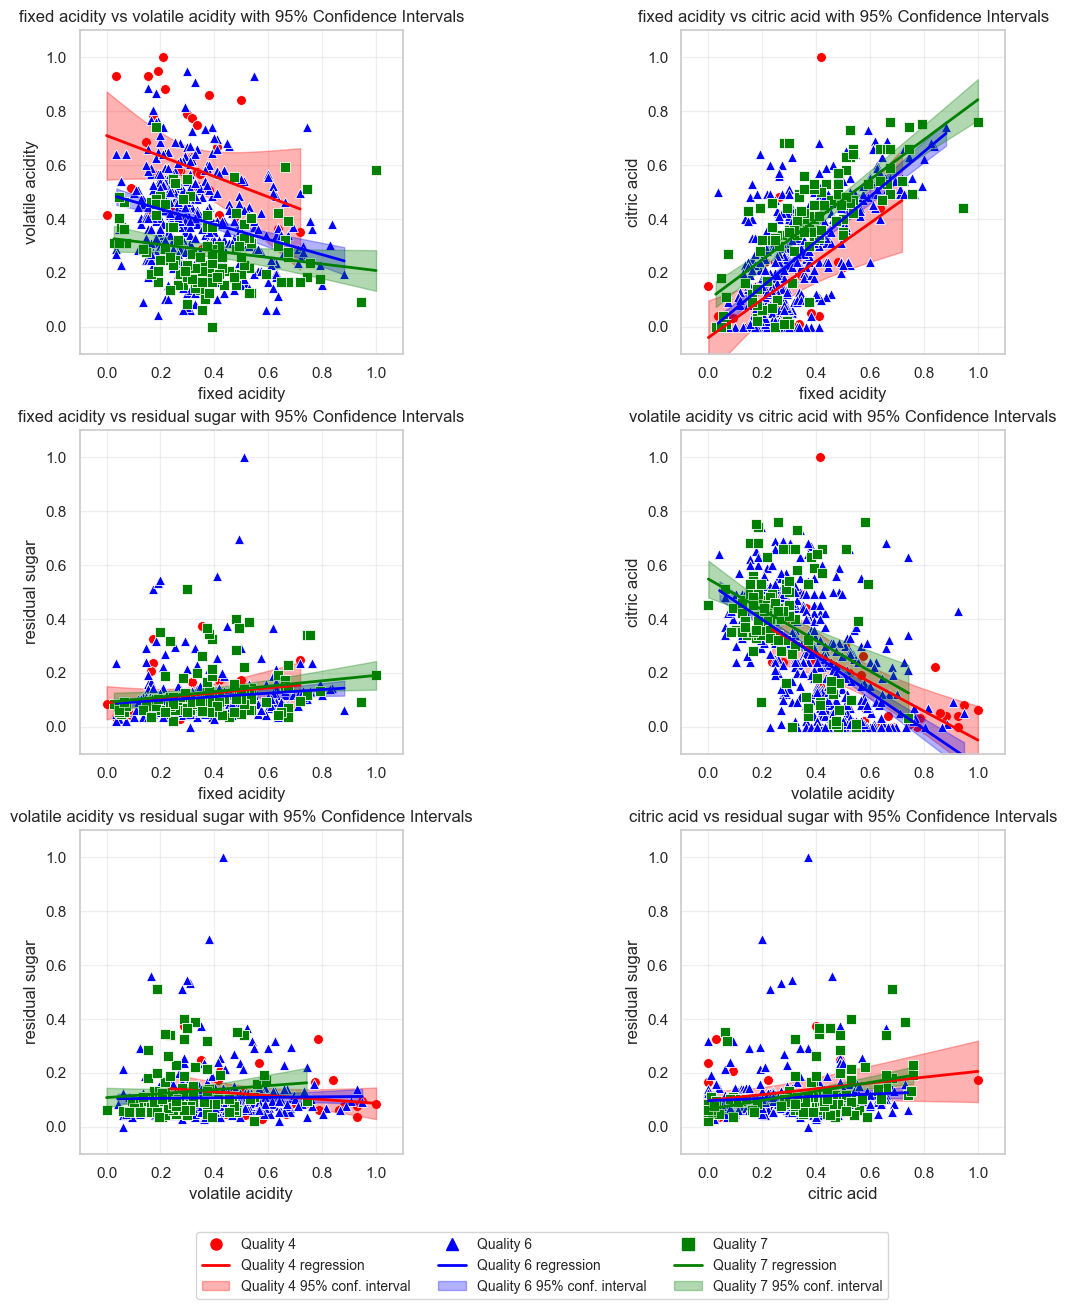

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats

%matplotlib inline

df = pd.read_csv('filtered_WineQT.csv')

class_styles = {
    4: {'color': 'red', 'marker': 'o', 'label': 'Quality 4'},
    6: {'color': 'blue', 'marker': '^', 'label': 'Quality 6'},
    7: {'color': 'green', 'marker': 's', 'label': 'Quality 7'}
}

sns.set_theme(style="whitegrid")

selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar']
pairs = list(itertools.combinations(selected_features, 2))

# Нормализация данных
df_norm = df.copy()
for feature in selected_features:
    df_norm[feature] = (df[feature] - df[feature].min()) / (df[feature].max() - df[feature].min())

def add_regression_line(ax, x_data, y_data, color, label, alpha=0.3, show_regression_label=False, show_interval_label=False):
    if len(x_data) < 2:
        return None, None  # Возвращаем None, если нет данных для регрессии
    
    # Подготовка данных как одномерных массивов
    x = x_data.values.flatten()
    y = y_data.values.flatten()
    
    # Линейная регрессия
    model = LinearRegression()
    X = x.reshape(-1, 1)
    model.fit(X, y)
    
    # Создание точек для плавной линии
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    
    # РАСЧЕТ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ (confidence intervals)
    # Статистические параметры
    n = len(y)
    k = 1  # количество предикторов (только X)
    df = n - k - 1  # степени свободы
    
    # Предсказания и остатки
    y_pred = model.predict(X)
    residuals = y - y_pred
    mse = np.mean(residuals**2)
    
    # Стандартная ошибка для коэффициентов
    X_design = np.column_stack([np.ones(n), x])  # Дизайн-матрица
    XTX_inv = np.linalg.inv(X_design.T @ X_design)
    se_b = np.sqrt(mse * np.diag(XTX_inv))
    
    # t-критическое значение для 95% доверительного интервала
    t_critical = stats.t.ppf(0.975, df)  # 97.5% квантиль для двухстороннего интервала
    
    # Стандартная ошибка среднего предсказания для доверительных интервалов
    # Для каждого нового x: se_mean = sqrt(mse * x_new^T * (X^T X)^(-1) * x_new)
    X_line_design = np.column_stack([np.ones(len(x_line)), x_line.flatten()])
    se_mean_line = np.sqrt(mse * np.diag(X_line_design @ XTX_inv @ X_line_design.T))
    
    # Доверительные интервалы для среднего (не для отдельных предсказаний)
    y_lower_ci = y_line.flatten() - t_critical * se_mean_line
    y_upper_ci = y_line.flatten() + t_critical * se_mean_line
    
    line_handle, = ax.plot(x_line.flatten(), y_line.flatten(), color=color, linewidth=2, label=None)
    interval_handle = ax.fill_between(x_line.flatten(), y_lower_ci, y_upper_ci, color=color, alpha=alpha, label=None)
    
    return line_handle, interval_handle

def create_legend_handles():
    handles = []
    labels = []
    for quality in sorted(class_styles.keys()):
        style = class_styles[quality]
        # Создаем placeholder для точки
        point_handle, = plt.plot([], [], color=style['color'], marker=style['marker'], 
                                linestyle='', markersize=8, label=style['label'])
        # Создаем placeholder для линии регрессии
        line_handle, = plt.plot([], [], color=style['color'], linewidth=2, 
                               label=f'{style["label"]} regression')
        # Создаем placeholder для интервала (используем patch)
        from matplotlib.patches import Patch
        interval_patch = Patch(color=style['color'], alpha=0.3, 
                              label=f'{style["label"]} 95% conf. interval')
        
        handles.extend([point_handle, line_handle, interval_patch])
        labels.extend([style['label'], f'{style["label"]} regression', 
                      f'{style["label"]} 95% conf. interval'])
    
    return handles, labels

# Диаграммы рассеяния с линиями регрессии и ДОВЕРИТЕЛЬНЫМИ интервалами
fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
axes = axes.flatten()

for i, (x_feature, y_feature) in enumerate(pairs):
    ax = axes[i]
    
    # Построение точек для каждого класса
    for quality in sorted(class_styles.keys()):
        subset = df_norm[df_norm['quality'] == quality]
        if len(subset) > 0:
            style = class_styles[quality]
            sns.scatterplot(data=subset, x=x_feature, y=y_feature, 
                            color=style['color'], 
                            marker=style['marker'], 
                            label='_nolegend_',
                            s=50, ax=ax)
            
            # Добавление линии регрессии с доверительными интервалами для этого класса
            add_regression_line(ax, subset[x_feature], subset[y_feature], 
                              style['color'], 
                              style['label'])
    
    ax.set_aspect('equal')  # Квадратное соотношение сторон
    ax.set_xlim(-0.1, 1.1)  # Унифицированный масштаб
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(f'{x_feature} vs {y_feature} with 95% Confidence Intervals')
    ax.grid(True, alpha=0.3)

# Удаление пустых subplot'ов
for j in range(len(pairs), len(axes)):
    fig.delaxes(axes[j])

# Добавляем общую легенду внизу
handles, labels = create_legend_handles()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, -0.05), 
           ncol=3, fontsize='small')
plt.show()

# [7]

In [18]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from scipy.stats import chi2, t
import itertools

df = pd.read_csv('filtered_WineQT.csv')

selected_classes = [4, 6, 7]
selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar']

pairs = list(itertools.combinations(selected_features, 2))

def get_regression_stats(subset, x_feature, y_feature):
    if len(subset) < 2:
        return None
   
    X = sm.add_constant(subset[x_feature])
    y = subset[y_feature]
    model = sm.OLS(y, X).fit()
   
    # Формула регрессии
    b0 = model.params[0]
    b1 = model.params[1]
    formula = f"{y_feature} = {b0:.4f} + {b1:.4f} × {x_feature}"
   
    r2 = model.rsquared
   
    # Критерий Вальда (F-критерий модели)
    wald_f = model.fvalue
    wald_df1 = model.df_model
    wald_df2 = model.df_resid
    wald_p = model.f_pvalue
   
    # Критерий LR (Likelihood Ratio test)
    null_model = sm.OLS(y, np.ones((len(y), 1))).fit() # null model: только intercept
    ll_null = null_model.llf
    ll_model = model.llf
    lr_chi2 = -2 * (ll_null - ll_model)
    lr_df = 1 # для одного предиктора
    lr_p = chi2.sf(lr_chi2, lr_df)  # Используем chi2 из scipy.stats
    
    # Критерий Score (Lagrange Multiplier test)
    # Используем t-тест для коэффициента как эквивалент
    t_stat = model.tvalues[1] # t-статистика для коэффициента при x
    df_score = model.df_resid
    score_chi2 = t_stat**2 # χ² = t²
    score_df = 1
    score_p = 2 * (1 - t.cdf(np.abs(t_stat), df_score)) # двухсторонний t-тест
    
    return {
        'Formula': formula,
        'R2': round(r2, 4),
        'Wald_F': round(wald_f, 4),
        'Wald_df1': int(wald_df1),
        'Wald_df2': int(wald_df2),
        'Wald_p': f"{wald_p:.4e}",
        'LR_chi2': round(lr_chi2, 4),
        'LR_df': int(lr_df),
        'LR_p': f"{lr_p:.4e}",
        'Score_chi2': round(score_chi2, 4),
        'Score_df': int(score_df),
        'Score_p': f"{score_p:.4e}"
    }

# Сбор результатов
results = []
for quality in selected_classes:
    subset = df[df['quality'] == quality]
    if len(subset) < 2:
        continue
   
    print(f"Обработка класса Quality {quality} (n={len(subset)} объектов)")
   
    for x_feature, y_feature in pairs:
        stats = get_regression_stats(subset, x_feature, y_feature)
        if stats:
            stats['Quality'] = quality
            stats['Pair'] = f"{x_feature} → {y_feature}"
            results.append(stats)
            print(f"  {x_feature} → {y_feature}: R² = {stats['R2']:.3f}")

# Создание таблицы
results_df = pd.DataFrame(results)
results_df = results_df[['Quality', 'Pair', 'Formula', 'R2', 'Wald_F', 'Wald_df1', 'Wald_df2', 'Wald_p',
                         'LR_chi2', 'LR_df', 'LR_p', 'Score_chi2', 'Score_df', 'Score_p']]

# Форматирование таблицы для лучшей читаемости
def format_pvalue(p):
    if float(p) < 0.001:
        return '<0.001'
    else:
        return f"{float(p):.4f}"

results_df['Wald_p'] = results_df['Wald_p'].apply(format_pvalue)
results_df['LR_p'] = results_df['LR_p'].apply(format_pvalue)
results_df['Score_p'] = results_df['Score_p'].apply(format_pvalue)

print("\n" + "="*120)
print("СТАТИСТИКИ ЛИНЕЙНЫХ РЕГРЕССИЙ ДЛЯ ВСЕХ ПАР ПРИЗНАКОВ И КЛАССОВ")
print("="*120)
print(results_df.to_string(index=False, float_format='%.4f'))

# Группировка по классам для более компактного вывода
print("\n" + "="*80)
print("СВОДКА ПО КЛАССАМ")
print("="*80)

summary_by_class = []
for quality in selected_classes:
    class_data = results_df[results_df['Quality'] == quality]
    if len(class_data) > 0:
        avg_r2 = class_data['R2'].mean()
        # Исправляем обработку p-value с '<0.001'
        def parse_pvalue(p_str):
            if '<' in str(p_str):
                return 0.0001  # очень маленькое значение
            else:
                return float(p_str)
        
        significant_wald = (class_data['Wald_p'].apply(parse_pvalue) < 0.05).sum()
        significant_lr = (class_data['LR_p'].apply(parse_pvalue) < 0.05).sum()
        significant_score = (class_data['Score_p'].apply(parse_pvalue) < 0.05).sum()
        
        summary_by_class.append({
            'Quality': quality,
            'N_pairs': len(class_data),
            'Avg_R2': round(avg_r2, 4),
            'Significant_Wald': f"{significant_wald}/{len(class_data)}",
            'Significant_LR': f"{significant_lr}/{len(class_data)}",
            'Significant_Score': f"{significant_score}/{len(class_data)}"
        })

summary_df = pd.DataFrame(summary_by_class)
print(summary_df.to_string(index=False))

print("\n" + "="*60)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("="*60)
if len(results_df) > 0:
    best_models = results_df.nlargest(3, 'R2')
    print("ТОП-3 МОДЕЛИ ПО R²:")
    for idx, row in best_models.iterrows():
        print(f"  {row['Quality']:2d}: {row['Pair']:25s} R²={row['R2']:5.3f} (p_Wald={row['Wald_p']})")
    
    total_significant = (results_df['Wald_p'].apply(lambda x: parse_pvalue(x) < 0.05)).sum()
    print(f"\nОБЩЕЕ КОЛИЧЕСТВО ЗНАЧИМЫХ МОДЕЛЕЙ (p<0.05): {total_significant}/{len(results_df)}")
    
    print("\nСРАВНЕНИЕ ТЕСТОВ (средние значения):")
    print(f"  Wald F:    {results_df['Wald_F'].mean():7.3f}")
    print(f"  LR χ²:     {results_df['LR_chi2'].mean():7.3f}")
    print(f"  Score χ²:  {results_df['Score_chi2'].mean():7.3f}")
    print(f"  Разность:  {abs(results_df['Wald_F'].mean() - results_df['LR_chi2'].mean()):7.3f}")

Обработка класса Quality 4 (n=33 объектов)
  fixed acidity → volatile acidity: R² = 0.068
  fixed acidity → citric acid: R² = 0.264
  fixed acidity → residual sugar: R² = 0.029
  volatile acidity → citric acid: R² = 0.322
  volatile acidity → residual sugar: R² = 0.037
  citric acid → residual sugar: R² = 0.077
Обработка класса Quality 6 (n=462 объектов)
  fixed acidity → volatile acidity: R² = 0.076
  fixed acidity → citric acid: R² = 0.472
  fixed acidity → residual sugar: R² = 0.015
  volatile acidity → citric acid: R² = 0.325
  volatile acidity → residual sugar: R² = 0.000
  citric acid → residual sugar: R² = 0.008
Обработка класса Quality 7 (n=143 объектов)
  fixed acidity → volatile acidity: R² = 0.028
  fixed acidity → citric acid: R² = 0.515
  fixed acidity → residual sugar: R² = 0.039
  volatile acidity → citric acid: R² = 0.158
  volatile acidity → residual sugar: R² = 0.011
  citric acid → residual sugar: R² = 0.114

СТАТИСТИКИ ЛИНЕЙНЫХ РЕГРЕССИЙ ДЛЯ ВСЕХ ПАР ПРИЗНАКОВ И КЛА

# [8]

ОДНОФАКТОРНЫЙ ANOVA ДЛЯ ВСЕХ КЛАССОВ
F-статистика: 6.3972
Степени свободы: df1=2, df2=635
p-value: 1.7756e-03
Результат: Различия между классами статистически значимы (p < 0.05)

ПАРНЫЕ СРАВНЕНИЯ КЛАССОВ (t-тест)
4 vs 6:
  t-статистика: -1.5984
  Степени свободы: 493
  p-value: 1.1060e-01
  Результат: Незначимо (p >= 0.05)
4 vs 7:
  t-статистика: -2.6519
  Степени свободы: 174
  p-value: 8.7442e-03
  Результат: Значимо (p < 0.05)
6 vs 7:
  t-статистика: -3.0034
  Степени свободы: 603
  p-value: 2.7807e-03
  Результат: Значимо (p < 0.05)

ТАБЛИЦА ПАРНЫХ СРАВНЕНИЙ
                  Pair  t_stat  df    p_value
Quality 4 vs Quality 6 -1.5984 493 1.1060e-01
Quality 4 vs Quality 7 -2.6519 174 8.7442e-03
Quality 6 vs Quality 7 -3.0034 603 2.7807e-03


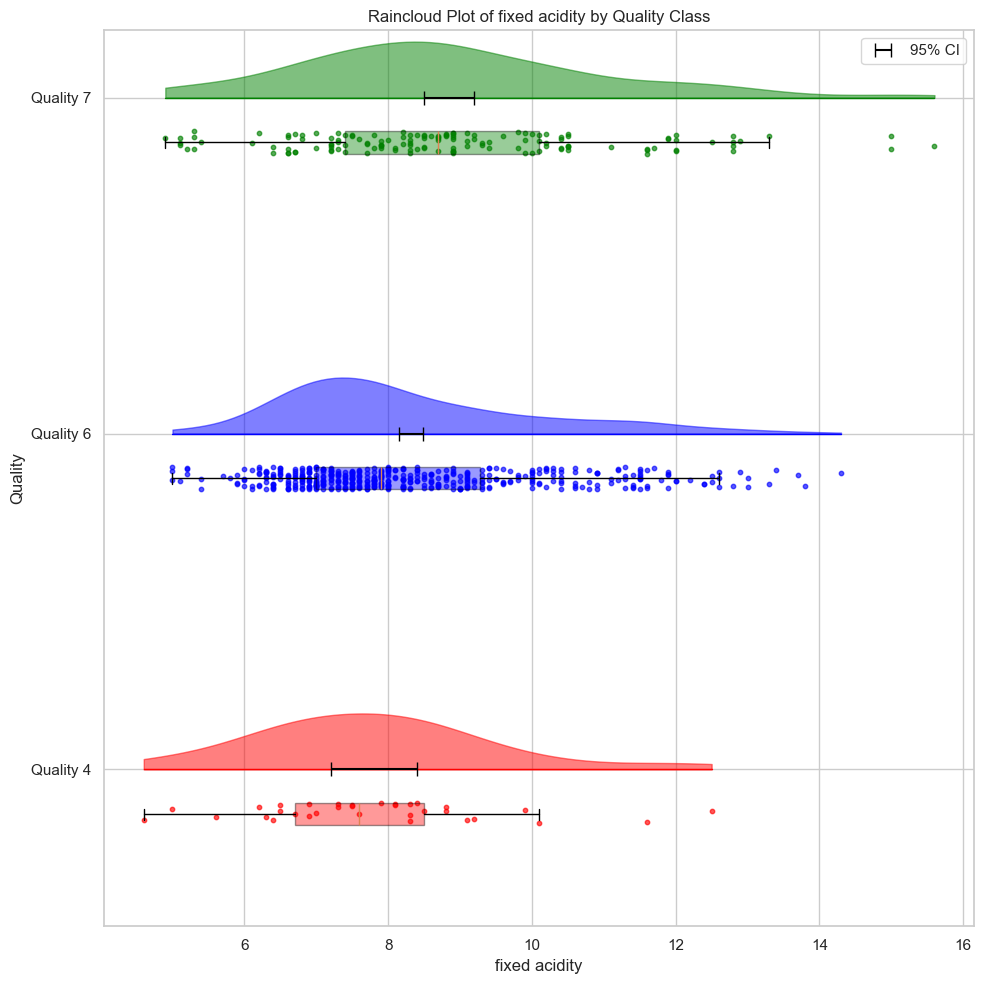

In [19]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, ttest_ind, sem, t
import matplotlib.pyplot as plt
import itertools

df = pd.read_csv('filtered_WineQT.csv')

selected_classes = [4, 6, 7]
selected_feature = 'fixed acidity'

data_by_class = [df[df['quality'] == q][selected_feature].values for q in selected_classes]

# 1. Однофакторный ANOVA для всех классов одновременно
f_stat, f_pvalue = f_oneway(*data_by_class)

# Степени свободы
k = len(selected_classes)  # количество групп
n = sum(len(data) for data in data_by_class)  # общее количество наблюдений
anova_df1 = k - 1  # степени свободы между группами
anova_df2 = n - k  # степени свободы внутри групп

# Вывод результатов ANOVA
print("="*60)
print("ОДНОФАКТОРНЫЙ ANOVA ДЛЯ ВСЕХ КЛАССОВ")
print("="*60)
print(f"F-статистика: {f_stat:.4f}")
print(f"Степени свободы: df1={anova_df1}, df2={anova_df2}")
print(f"p-value: {f_pvalue:.4e}")
if f_pvalue < 0.05:
    print("Результат: Различия между классами статистически значимы (p < 0.05)")
else:
    print("Результат: Нет статистически значимых различий между классами (p >= 0.05)")

# 2. Парное сравнение классов (t-тест)
print("\n" + "="*60)
print("ПАРНЫЕ СРАВНЕНИЯ КЛАССОВ (t-тест)")
print("="*60)
pairwise_results = []
for (q1, q2) in itertools.combinations(selected_classes, 2):
    data1 = df[df['quality'] == q1][selected_feature]
    data2 = df[df['quality'] == q2][selected_feature]
    
    # t-тест (двухсторонний, предполагаем равные дисперсии)
    t_stat, t_pvalue = ttest_ind(data1, data2, equal_var=True)
    
    # Степени свободы
    df_t = len(data1) + len(data2) - 2
    
    pairwise_results.append({
        'Pair': f"Quality {q1} vs Quality {q2}",
        't_stat': round(t_stat, 4),
        'df': int(df_t),
        'p_value': f"{t_pvalue:.4e}"
    })
    
    print(f"{q1} vs {q2}:")
    print(f"  t-статистика: {t_stat:.4f}")
    print(f"  Степени свободы: {df_t}")
    print(f"  p-value: {t_pvalue:.4e}")
    print(f"  Результат: {'Значимо' if t_pvalue < 0.05 else 'Незначимо'} (p {'< 0.05' if t_pvalue < 0.05 else '>= 0.05'})")

# Создание таблицы парных сравнений
pairwise_df = pd.DataFrame(pairwise_results)
print("\n" + "="*60)
print("ТАБЛИЦА ПАРНЫХ СРАВНЕНИЙ")
print("="*60)
print(pairwise_df.to_string(index=False))

# 3. Визуализация: Raincloud plot с группировкой по классам
fig, ax = plt.subplots(figsize=(10, 10))

# Цвета для классов (строковые ключи)
colors = {'4': 'red', '6': 'blue', '7': 'green'}

# Базовый y-уровень для каждого класса и смещения внутри группы
base_offsets = [1, 2.5, 4.0]
violin_height = 0.4
strip_offset = -0.2
box_offset = -0.2
ci_offset = 0.0

for i, q in enumerate(selected_classes):
    base_y = base_offsets[i]
    data = df[df['quality'] == q][selected_feature]
    
    # Половиолинный график
    vp = ax.violinplot(data, positions=[base_y], showmeans=False, 
                       showextrema=False, showmedians=False, vert=False)
    for b in vp['bodies']:
        m = np.mean(b.get_paths()[0].vertices[:, 0])  # Центр violin
        b.get_paths()[0].vertices[:, 1] = np.clip(b.get_paths()[0].vertices[:, 1], 
                                                  base_y, base_y + violin_height)
        b.set_color(colors[str(q)])
        b.set_alpha(0.5)
    ax.plot([data.min(), data.max()], [base_y, base_y], color=colors[str(q)], linewidth=1)  # Линия основания
    
    # Точки с джиттером
    y = np.full_like(data, base_y + strip_offset)
    y += np.random.uniform(low=-0.05, high=0.05, size=len(data))  # Джиттер
    ax.scatter(data, y, s=10, color=colors[str(q)], alpha=0.65)
    
    # Боксплот
    bp = ax.boxplot(data, positions=[base_y + box_offset], widths=0.1, 
                    patch_artist=True, vert=False, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor(colors[str(q)])
        patch.set_alpha(0.4)
    
    # Доверительный интервал (95% CI)
    mean = data.mean()
    sem_val = sem(data)
    ci = sem_val * t.ppf(0.975, len(data) - 1)
    ax.errorbar(mean, base_y + ci_offset, xerr=ci, fmt='none', c='black', 
                capsize=5, linewidth=1.5, label='95% CI' if i == 0 else None)

# Настройка осей
ax.set_yticks(base_offsets)
ax.set_yticklabels([f'Quality {q}' for q in selected_classes])
ax.set_xlabel(selected_feature)
ax.set_ylabel('Quality')
ax.set_title(f'Raincloud Plot of {selected_feature} by Quality Class')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# [9]


АНАЛИЗ ДЛЯ ПРИЗНАКА: VOLATILE ACIDITY
ОДНОФАКТОРНЫЙ ANOVA ДЛЯ ВСЕХ КЛАССОВ
F-статистика: 58.0221
Степени свободы: df1=2, df2=635
p-value: 7.1921e-24
Результат: Различия между классами статистически значимы (p < 0.05)

ПАРНЫЕ СРАВНЕНИЯ КЛАССОВ (t-тест)
4 vs 6:
  t-статистика: 6.6032
  Степени свободы: 493
  p-value: 1.0433e-10
  Результат: Значимо (p < 0.05)
4 vs 7:
  t-статистика: 10.4096
  Степени свободы: 174
  p-value: 4.9318e-20
  Результат: Значимо (p < 0.05)
6 vs 7:
  t-статистика: 7.5538
  Степени свободы: 603
  p-value: 1.5751e-13
  Результат: Значимо (p < 0.05)

ТАБЛИЦА ПАРНЫХ СРАВНЕНИЙ
                  Pair  t_stat  df    p_value
Quality 4 vs Quality 6  6.6032 493 1.0433e-10
Quality 4 vs Quality 7 10.4096 174 4.9318e-20
Quality 6 vs Quality 7  7.5538 603 1.5751e-13


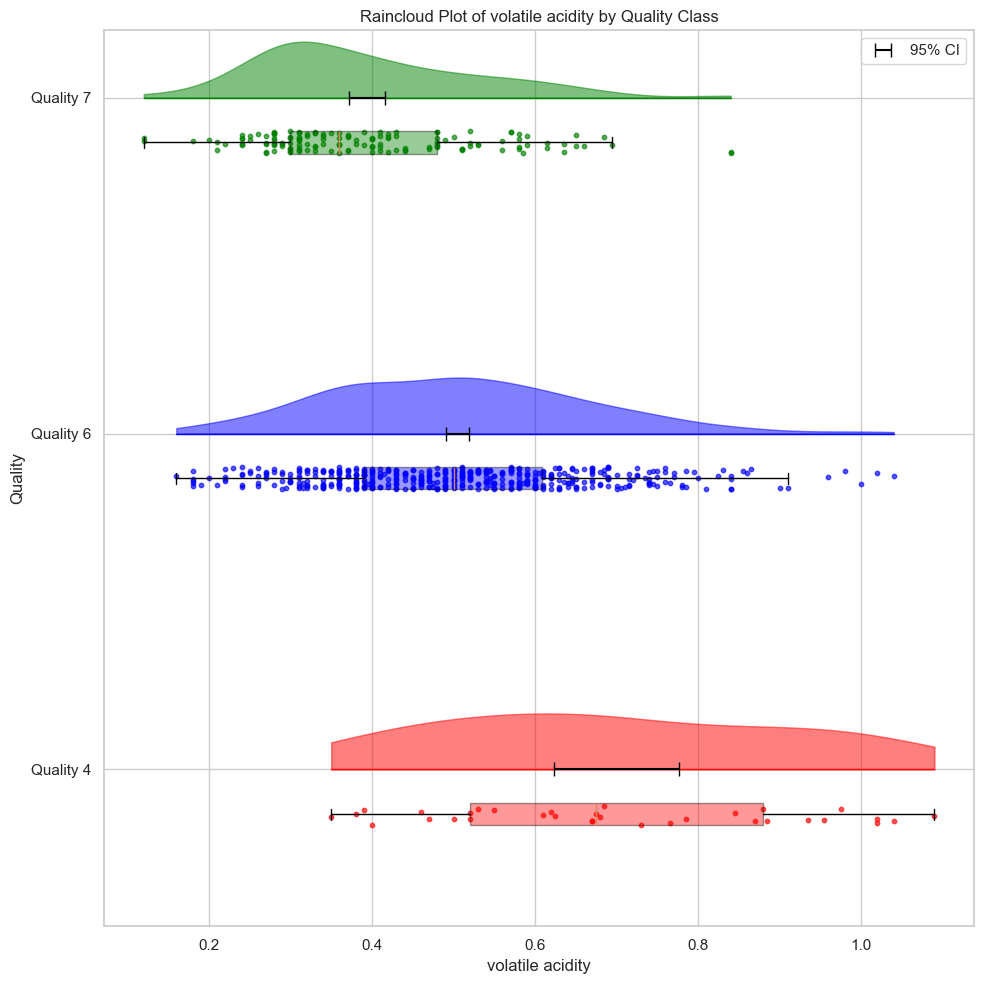


АНАЛИЗ ДЛЯ ПРИЗНАКА: CITRIC ACID
ОДНОФАКТОРНЫЙ ANOVA ДЛЯ ВСЕХ КЛАССОВ
F-статистика: 27.8174
Степени свободы: df1=2, df2=635
p-value: 2.6259e-12
Результат: Различия между классами статистически значимы (p < 0.05)

ПАРНЫЕ СРАВНЕНИЯ КЛАССОВ (t-тест)
4 vs 6:
  t-статистика: -2.7664
  Степени свободы: 493
  p-value: 5.8812e-03
  Результат: Значимо (p < 0.05)
4 vs 7:
  t-статистика: -5.7065
  Степени свободы: 174
  p-value: 4.8737e-08
  Результат: Значимо (p < 0.05)
6 vs 7:
  t-статистика: -6.5539
  Степени свободы: 603
  p-value: 1.2041e-10
  Результат: Значимо (p < 0.05)

ТАБЛИЦА ПАРНЫХ СРАВНЕНИЙ
                  Pair  t_stat  df    p_value
Quality 4 vs Quality 6 -2.7664 493 5.8812e-03
Quality 4 vs Quality 7 -5.7065 174 4.8737e-08
Quality 6 vs Quality 7 -6.5539 603 1.2041e-10


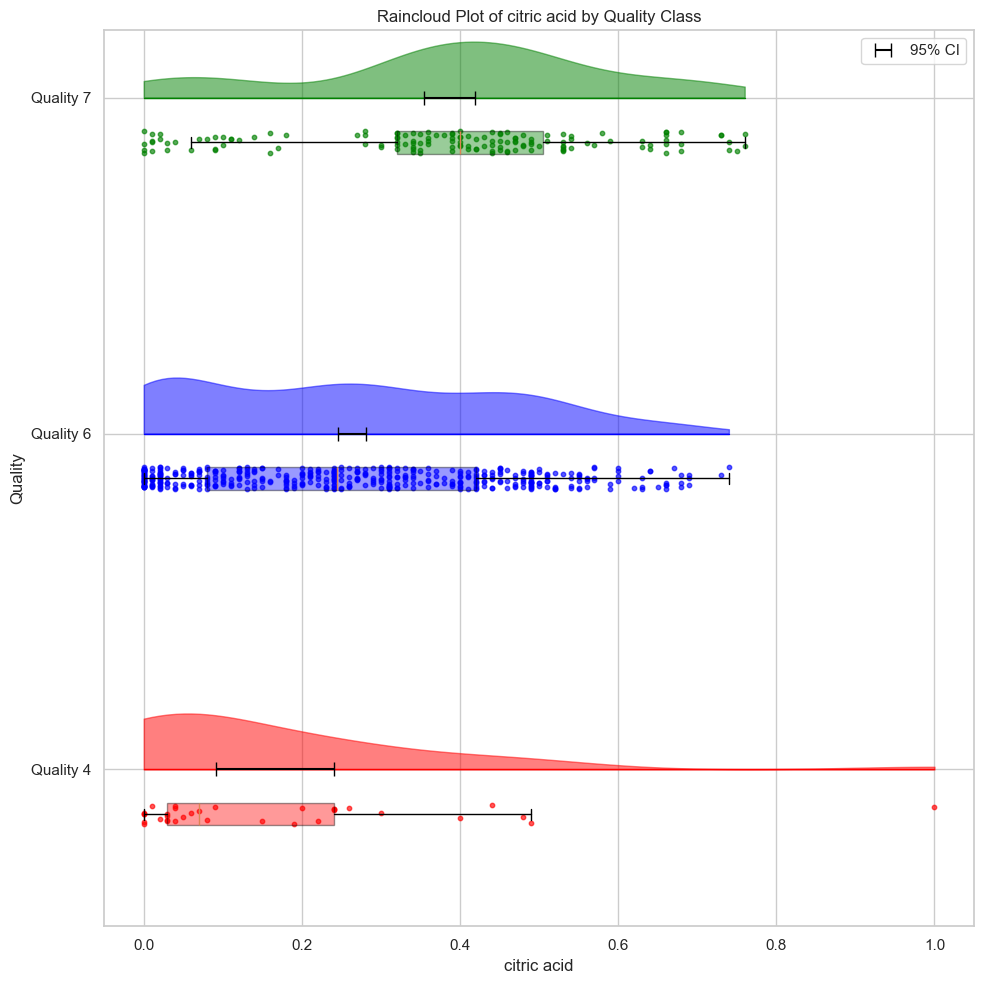


АНАЛИЗ ДЛЯ ПРИЗНАКА: RESIDUAL SUGAR
ОДНОФАКТОРНЫЙ ANOVA ДЛЯ ВСЕХ КЛАССОВ
F-статистика: 3.2898
Степени свободы: df1=2, df2=635
p-value: 3.7899e-02
Результат: Различия между классами статистически значимы (p < 0.05)

ПАРНЫЕ СРАВНЕНИЯ КЛАССОВ (t-тест)
4 vs 6:
  t-статистика: 0.5402
  Степени свободы: 493
  p-value: 5.8928e-01
  Результат: Незначимо (p >= 0.05)
4 vs 7:
  t-статистика: -0.7303
  Степени свободы: 174
  p-value: 4.6618e-01
  Результат: Незначимо (p >= 0.05)
6 vs 7:
  t-статистика: -2.5469
  Степени свободы: 603
  p-value: 1.1116e-02
  Результат: Значимо (p < 0.05)

ТАБЛИЦА ПАРНЫХ СРАВНЕНИЙ
                  Pair  t_stat  df    p_value
Quality 4 vs Quality 6  0.5402 493 5.8928e-01
Quality 4 vs Quality 7 -0.7303 174 4.6618e-01
Quality 6 vs Quality 7 -2.5469 603 1.1116e-02


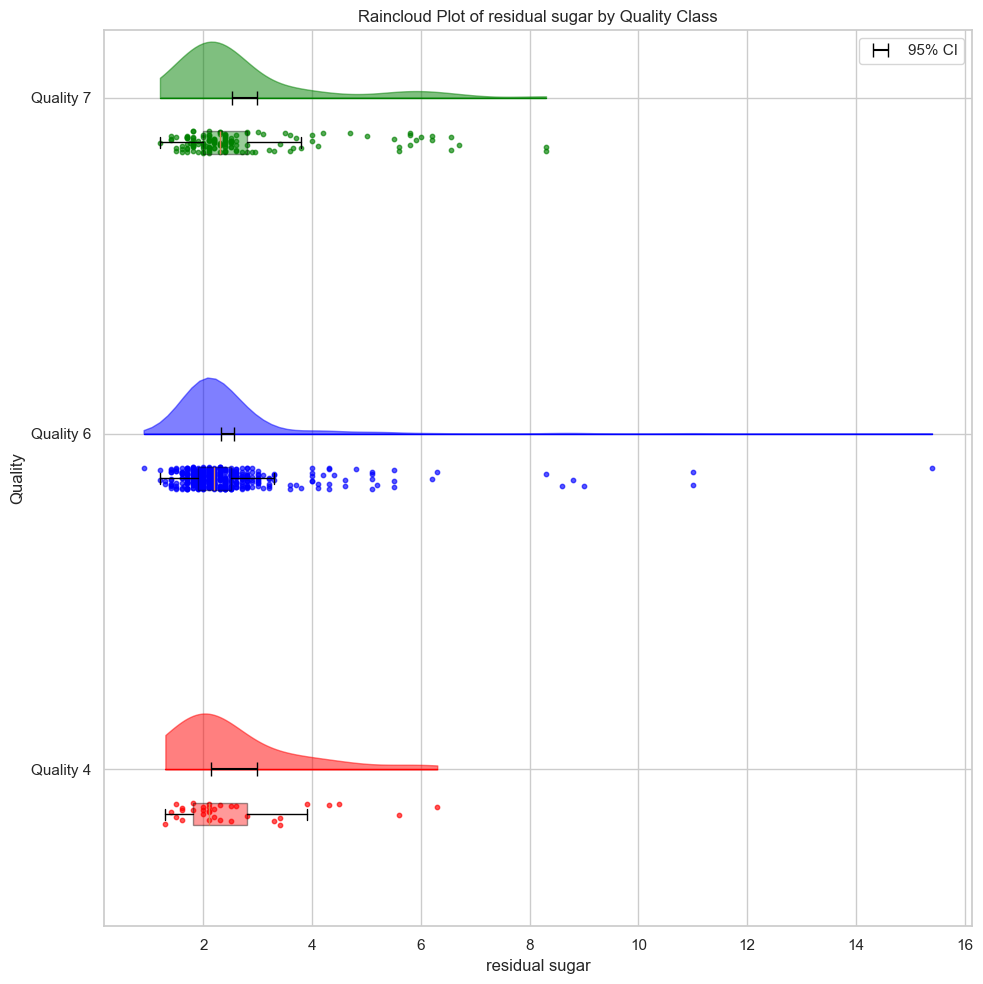

In [20]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, ttest_ind, sem, t
import matplotlib.pyplot as plt
import itertools


df = pd.read_csv('filtered_WineQT.csv')

selected_classes = [4, 6, 7]
selected_features = ['volatile acidity', 'citric acid', 'residual sugar']

colors = {'4': 'red', '6': 'blue', '7': 'green'}

# Базовый y-уровень для каждого класса и смещения внутри группы
base_offsets = [1, 2.5, 4.0]
violin_height = 0.4
strip_offset = -0.2
box_offset = -0.2
ci_offset = 0.0

# Итерация по каждому признаку
for selected_feature in selected_features:
    print("\n" + "="*60)
    print(f"АНАЛИЗ ДЛЯ ПРИЗНАКА: {selected_feature.upper()}")
    print("="*60)

    # Подготовка данных
    data_by_class = [df[df['quality'] == q][selected_feature].values for q in selected_classes]

    # 1. Однофакторный ANOVA для всех классов одновременно
    f_stat, f_pvalue = f_oneway(*data_by_class)

    # Степени свободы
    k = len(selected_classes)  # количество групп
    n = sum(len(data) for data in data_by_class)  # общее количество наблюдений
    anova_df1 = k - 1  # степени свободы между группами
    anova_df2 = n - k  # степени свободы внутри групп

    # Вывод результатов ANOVA
    print("ОДНОФАКТОРНЫЙ ANOVA ДЛЯ ВСЕХ КЛАССОВ")
    print("="*60)
    print(f"F-статистика: {f_stat:.4f}")
    print(f"Степени свободы: df1={anova_df1}, df2={anova_df2}")
    print(f"p-value: {f_pvalue:.4e}")
    if f_pvalue < 0.05:
        print("Результат: Различия между классами статистически значимы (p < 0.05)")
    else:
        print("Результат: Нет статистически значимых различий между классами (p >= 0.05)")

    # 2. Парное сравнение классов (t-тест)
    print("\n" + "="*60)
    print("ПАРНЫЕ СРАВНЕНИЯ КЛАССОВ (t-тест)")
    print("="*60)
    pairwise_results = []
    for (q1, q2) in itertools.combinations(selected_classes, 2):
        data1 = df[df['quality'] == q1][selected_feature]
        data2 = df[df['quality'] == q2][selected_feature]
        
        # t-тест (двухсторонний, предполагаем равные дисперсии)
        t_stat, t_pvalue = ttest_ind(data1, data2, equal_var=True)
        
        # Степени свободы
        df_t = len(data1) + len(data2) - 2
        
        pairwise_results.append({
            'Pair': f"Quality {q1} vs Quality {q2}",
            't_stat': round(t_stat, 4),
            'df': int(df_t),
            'p_value': f"{t_pvalue:.4e}"
        })
        
        print(f"{q1} vs {q2}:")
        print(f"  t-статистика: {t_stat:.4f}")
        print(f"  Степени свободы: {df_t}")
        print(f"  p-value: {t_pvalue:.4e}")
        print(f"  Результат: {'Значимо' if t_pvalue < 0.05 else 'Незначимо'} (p {'< 0.05' if t_pvalue < 0.05 else '>= 0.05'})")

    # Создание таблицы парных сравнений
    pairwise_df = pd.DataFrame(pairwise_results)
    print("\n" + "="*60)
    print("ТАБЛИЦА ПАРНЫХ СРАВНЕНИЙ")
    print("="*60)
    print(pairwise_df.to_string(index=False))

    # 3. Визуализация: Raincloud plot с группировкой по классам
    fig, ax = plt.subplots(figsize=(10, 10))

    for i, q in enumerate(selected_classes):
        base_y = base_offsets[i]
        data = df[df['quality'] == q][selected_feature]
        
        # Половиолинный график (верхняя половина)
        vp = ax.violinplot(data, positions=[base_y], showmeans=False, 
                           showextrema=False, showmedians=False, vert=False)
        for b in vp['bodies']:
            m = np.mean(b.get_paths()[0].vertices[:, 0])  # Центр violin
            b.get_paths()[0].vertices[:, 1] = np.clip(b.get_paths()[0].vertices[:, 1], 
                                                      base_y, base_y + violin_height)
            b.set_color(colors[str(q)])
            b.set_alpha(0.5)
        ax.plot([data.min(), data.max()], [base_y, base_y], color=colors[str(q)], 
                linewidth=1)  # Линия основания
        
        # Точки с джиттером
        y = np.full_like(data, base_y + strip_offset)
        y += np.random.uniform(low=-0.05, high=0.05, size=len(data))  # Джиттер
        ax.scatter(data, y, s=10, color=colors[str(q)], alpha=0.65)
        
        # Боксплот
        bp = ax.boxplot(data, positions=[base_y + box_offset], widths=0.1, 
                        patch_artist=True, vert=False, showfliers=False)
        for patch in bp['boxes']:
            patch.set_facecolor(colors[str(q)])
            patch.set_alpha(0.4)
        
        # Доверительный интервал (95% CI)
        mean = data.mean()
        sem_val = sem(data)
        ci = sem_val * t.ppf(0.975, len(data) - 1) # 95% -> 2.5% at each end. Then 1 - 0.025 = 0.975
        ax.errorbar(mean, base_y + ci_offset, xerr=ci, fmt='none', c='black', 
                    capsize=5, linewidth=1.5, label='95% CI' if i == 0 else None)

    # Настройка осей
    ax.set_yticks(base_offsets)
    ax.set_yticklabels([f'Quality {q}' for q in selected_classes])
    ax.set_xlabel(selected_feature)
    ax.set_ylabel('Quality')
    ax.set_title(f'Raincloud Plot of {selected_feature} by Quality Class')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()